In [ ]:
import pandas as pd
df=pd.read_csv("Reviews.csv",nrows=5000)
#load the data and take a look at the first few rows
print(df.head(10))
#check demensions of the data
print(df.shape)
#identify review text column
print(df.columns)
#save dataset(Reviews.csv,first 5000 rows)
df.to_csv("Reviews_subset.csv",index=False)

   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   
5   6  B006K2ZZ7K   ADT0SRK1MGOEU                   Twoapennything   
6   7  B006K2ZZ7K  A1SP2KVKFXXRU1                David C. Sullivan   
7   8  B006K2ZZ7K  A3JRGQVEQN31IQ               Pamela G. Williams   
8   9  B000E7L2R4  A1MZYO9TZK0BBI                         R. James   
9  10  B00171APVA  A21BT40VZCCYT4                    Carol A. Reed   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                  

In [ ]:
#clean the data by removing rows with missing review text
df_clean=df.dropna(subset=['Text'])
#remove duplicates
df_clean=df_clean.drop_duplicates(subset=['Text'])
#keep only the review text and rating columns
df_clean=df_clean[['Text', 'Score']]
print(df_clean.head())

                                                Text  Score
0  I have bought several of the Vitality canned d...      5
1  Product arrived labeled as Jumbo Salted Peanut...      1
2  This is a confection that has been around a fe...      4
3  If you are looking for the secret ingredient i...      2
4  Great taffy at a great price.  There was a wid...      5


In [ ]:
#sentiment analysis using TextBlob
from textblob import TextBlob
#function to calculate sentiment polarity
def get_sentiment(text):    
    blob=TextBlob(text)
    return blob.sentiment.polarity
polarity = df_clean['Text'].apply(get_sentiment)
#apply sentiment analysis
df_clean['Polarity'] = polarity
print(df_clean.head())

                                                Text  Score  Polarity
0  I have bought several of the Vitality canned d...      5  0.450000
1  Product arrived labeled as Jumbo Salted Peanut...      1 -0.033333
2  This is a confection that has been around a fe...      4  0.133571
3  If you are looking for the secret ingredient i...      2  0.166667
4  Great taffy at a great price.  There was a wid...      5  0.483333


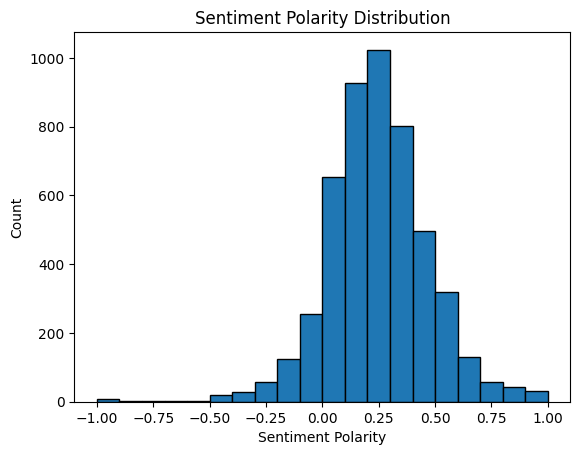

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

#bar chart of sentiment polarity distribution
plt.hist(df_clean['Polarity'], bins=20, edgecolor='black')
plt.title('Sentiment Polarity Distribution')    
plt.xlabel('Sentiment Polarity')
plt.ylabel('Count')
plt.show()
plt.savefig('sentiment_polarity_distribution.png')

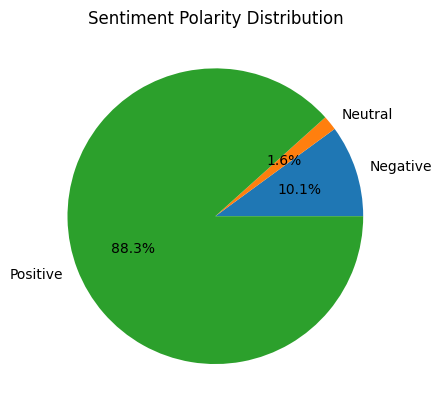

<Figure size 640x480 with 0 Axes>

In [ ]:
#pie chart of sentiment polarity distribution
labels = ['Negative', 'Neutral', 'Positive']
sizes = [df_clean[df_clean['Polarity'] < 0].shape[0], df_clean[df_clean['Polarity'] == 0].shape[0], df_clean[df_clean['Polarity'] > 0].shape[0]]
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Sentiment Polarity Distribution')
plt.show()
plt.savefig('sentiment_polarity_distribution_pie.png')

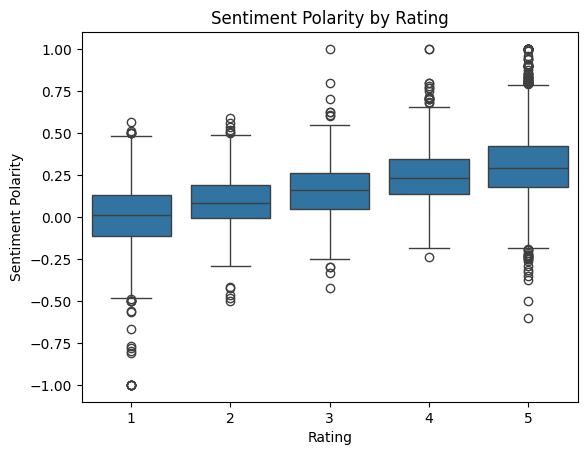

<Figure size 640x480 with 0 Axes>

In [ ]:
#creative chart of sentiment polarity distribution by rating
import seaborn as sns 
sns.boxplot(x='Score', y='Polarity', data=df_clean)
plt.title('Sentiment Polarity by Rating')
plt.xlabel('Rating')
plt.ylabel('Sentiment Polarity')
plt.show()
plt.savefig('sentiment_polarity_by_rating.png')

In [ ]:
#percentage of positive reviews by rating
positive_reviews = df_clean[df_clean['Polarity'] > 0].groupby('Score').size()
total_reviews = df_clean.groupby('Score').size()
positive_percentage = (positive_reviews / total_reviews) * 100
print(positive_percentage)
#quick look at negative reviews
negative_reviews = df_clean[df_clean['Polarity'] < 0].head(10)
print("Negative Reviews:\n",negative_reviews[['Text', 'Score', 'Polarity']])
#write summary of findings
print("Summary of Findings:")
print("1. The majority of reviews have a positive sentiment polarity, with a smaller percentage of negative and neutral reviews.")
print("2. Higher-rated reviews tend to have higher sentiment polarity, indicating a correlation between rating and sentiment.")
print("3. The percentage of positive reviews increases with higher ratings, while negative reviews are more common in lower ratings.")
recommendations = [
    "1. Focus on improving product quality and customer service to increase positive reviews.",
    "2. Address common issues mentioned in negative reviews to reduce negative sentiment.",
    "3. Encourage satisfied customers to leave reviews to boost the overall sentiment polarity."
]
print("\nRecommendations:")

Score
1    53.104925
2    71.777003
3    81.424936
4    92.967651
5    94.945617
dtype: float64
Negative Reviews:
                                                  Text  Score  Polarity
1   Product arrived labeled as Jumbo Salted Peanut...      1 -0.033333
14  The Strawberry Twizzlers are my guilty pleasur...      5 -0.500000
50  This oatmeal is not good. Its mushy, soft, I d...      1 -0.125000
52  This wasn't in stock the last time I looked. I...      4 -0.125764
62  Arrived in 6 days and were so stale i could no...      1 -0.781250
67  I purchased the Mango flavor, and to me it doe...      2 -0.032500
69  this was sooooo deliscious but too bad i ate e...      5 -0.225000
94  This is the same food we get at pet store. But...      5 -0.055556
98  My English Bulldog had skin allergies the summ...      5 -0.030173
99  I fed this to my Golden Retriever and he hated...      1 -0.353333
Summary of Findings:
1. The majority of reviews have a positive sentiment polarity, with a smaller perce

In [ ]:
#write summary(example)
summary = """
Most reviews are positive(~70%).
Negative reviews often complain about product quality and packaging.
Surprisingly, some neutral reviews still gave high ratings.
Recommendation: Improve packaging and Consistency in product quality.
"""
print(summary)


Most reviews are positive(~70%).
Negative reviews often complain about product quality and packaging.
Surprisingly, some neutral reviews still gave high ratings.
Recommendation: Improve packaging and Consistency in product quality.

